In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RAW = '../data/raw'
CLEAN = '../data/cleaned'
os.makedirs(CLEAN, exist_ok=True)

def clean_num(series):
    """Strip commas from numbers like '1,23,456' and convert to float."""
    return pd.to_numeric(
        series.astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    )

print("Setup complete.")

Setup complete.


In [2]:
# %% CELL 2 — Load & clean state accidents (2019–2023 OpenCity + 2024 PDF extract)
acc_2023 = pd.read_csv(f'{RAW}/state_accidents_2019_2023.csv', encoding='utf-8-sig')
acc_2023.columns = acc_2023.columns.str.strip()
print("state_accidents_2019_2023 columns:", acc_2023.columns.tolist())

acc_2024 = pd.read_csv(f'{RAW}/state_accidents_2024.csv')
print("state_accidents_2024 columns:", acc_2024.columns.tolist())

state_accidents_2019_2023 columns: ['Sl No', 'State', '2019 Accidents', '2020 Accidents', '2021 Accidents', '2022 Accidents', '2023 Accidents', 'Change from 2022 to 2023', '% change from 2022 to 2023', '2019 Ranking', '2020 Ranking', '2021 Ranking', '2022 Ranking', '2023 Ranking']
state_accidents_2024 columns: ['Sl No', 'State', '2020 Accidents', '2021 Accidents', '2022 Accidents', '2023 Accidents', '2024 Accidents', 'Change 2023 to 2024', '% Change 2023 to 2024', '2024 Ranking']


In [3]:
# %% CELL 3 — Build unified LONG format state accidents table
# OpenCity file has cols: Sl No, State, 2019 Accidents, 2020 Accidents, ... 2023 Accidents
year_cols_23 = [c for c in acc_2023.columns if 'Accident' in c and any(y in c for y in ['2019','2020','2021','2022','2023'])]
acc_long = acc_2023[['State'] + year_cols_23].copy()
acc_long.columns = ['state'] + [c.split()[0] for c in year_cols_23]  # keep just year number
acc_long = acc_long[acc_long['state'].notna() & ~acc_long['state'].astype(str).str.contains('Total', na=False)]

acc_long = acc_long.melt(id_vars='state', var_name='year', value_name='accidents')
acc_long['year'] = acc_long['year'].astype(int)
acc_long['accidents'] = clean_num(acc_long['accidents'])

# Add 2024 data from PDF extract
acc_2024_long = acc_2024[['State', '2024 Accidents']].copy()
acc_2024_long.columns = ['state', 'accidents']
acc_2024_long['year'] = 2024
acc_2024_long = acc_2024_long[acc_2024_long['accidents'].notna() & (acc_2024_long['state'] != 'Total')]

acc_all = pd.concat([acc_long, acc_2024_long], ignore_index=True)
acc_all['accidents'] = clean_num(acc_all['accidents'])
print(f"Accidents table: {acc_all.shape} | Years: {sorted(acc_all.year.unique())}")


Accidents table: (227, 3) | Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [4]:
# %% CELL 4 — Build unified LONG format state fatalities table
fat_2023 = pd.read_csv(f'{RAW}/state_fatalities_2019_2023.csv', encoding='utf-8-sig')
fat_2023.columns = fat_2023.columns.str.strip()

fat_2024 = pd.read_csv(f'{RAW}/state_fatalities_2024.csv')

year_cols_fat = [c for c in fat_2023.columns if 'Killed' in c and any(y in c for y in ['2019','2020','2021','2022','2023'])]
fat_long = fat_2023[['State'] + year_cols_fat].copy()
fat_long.columns = ['state'] + [c.split()[0] for c in year_cols_fat]
fat_long = fat_long[fat_long['state'].notna() & ~fat_long['state'].astype(str).str.contains('Total', na=False)]

fat_long = fat_long.melt(id_vars='state', var_name='year', value_name='fatalities')
fat_long['year'] = fat_long['year'].astype(int)
fat_long['fatalities'] = clean_num(fat_long['fatalities'])

fat_2024_long = fat_2024[['State', '2024 Killed']].copy()
fat_2024_long.columns = ['state', 'fatalities']
fat_2024_long['year'] = 2024
fat_2024_long = fat_2024_long[fat_2024_long['fatalities'].notna() & (fat_2024_long['state'] != 'Total')]

fat_all = pd.concat([fat_long, fat_2024_long], ignore_index=True)
fat_all['fatalities'] = clean_num(fat_all['fatalities'])
print(f"Fatalities table: {fat_all.shape} | Years: {sorted(fat_all.year.unique())}")

Fatalities table: (227, 3) | Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [5]:
# %% CELL 5 — Merge and engineer normalized risk metrics
state_master = acc_all.merge(fat_all, on=['state', 'year'], how='outer')

# vehicle_road_density is national-level only (not state-wise in source data)
# so we compute these ratio metrics from what we have:
state_master['fatality_rate_per_accident'] = (
    state_master['fatalities'] / state_master['accidents']
).round(4)

# YoY change in accidents per state
state_master = state_master.sort_values(['state', 'year'])
state_master['yoy_accident_change'] = state_master.groupby('state')['accidents'].diff()
state_master['yoy_fatality_change'] = state_master.groupby('state')['fatalities'].diff()

state_master.to_csv(f'{CLEAN}/state_master.csv', index=False)
print(f"state_master saved: {state_master.shape}")
print(state_master[state_master.year == 2024].nlargest(5, 'accidents')[['state','accidents','fatalities','fatality_rate_per_accident']])

state_master saved: (228, 7)
              state  accidents  fatalities  fatality_rate_per_accident
197      Tamil Nadu    67526.0     18449.0                      0.2732
131  Madhya Pradesh    56669.0     14791.0                      0.2610
113          Kerala    48834.0      3880.0                      0.0795
215   Uttar Pradesh    46052.0     24118.0                      0.5237
107       Karnataka    43062.0     12390.0                      0.2877


In [6]:
# Fix state name inconsistencies between OpenCity and 2024 CSV
name_map = {
    'Andaman & Nicobar Islands': 'Andaman & Nicobar Islands',
    'Andaman and Nicobar Islands': 'Andaman & Nicobar Islands',
    'Jammu and Kashmir': 'Jammu and Kashmir',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'D & N Haveli and Daman & Diu': 'D&N Haveli and Daman & Diu',
    'D&N Haveli and Daman & Diu': 'D&N Haveli and Daman & Diu',
}
state_master['state'] = state_master['state'].replace(name_map)
state_master = state_master.groupby(['state','year'], as_index=False).agg({
    'accidents': 'sum',
    'fatalities': 'sum',
    'fatality_rate_per_accident': 'mean',
    'yoy_accident_change': 'first',
    'yoy_fatality_change': 'first'
})
print(f"After dedup: {state_master.shape}")  # should be ~216
state_master.to_csv(f'{CLEAN}/state_master.csv', index=False)

After dedup: (228, 7)


In [7]:
print(f"Unique states: {state_master['state'].nunique()}")
print(sorted(state_master['state'].unique().tolist()))

Unique states: 42
['138383', '372181', 'All India', 'Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'D&N Haveli and Daman & Diu', 'Dadra & Nagar Haveli*', 'Daman & Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'J & K #', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [8]:
# Drop junk rows
junk = ['138383', '372181', 'All India']
state_master = state_master[~state_master['state'].isin(junk)]

# Fix name mismatches
name_map = {
    'J & K #':              'Jammu and Kashmir',
    'Dadra & Nagar Haveli*':'D&N Haveli and Daman & Diu',
    'Daman & Diu':          'D&N Haveli and Daman & Diu',
}
state_master['state'] = state_master['state'].replace(name_map)

# Re-aggregate after merge
state_master = state_master.groupby(['state','year'], as_index=False).agg({
    'accidents':                  'sum',
    'fatalities':                 'sum',
    'fatality_rate_per_accident': 'mean',
    'yoy_accident_change':        'first',
    'yoy_fatality_change':        'first'
})

print(f"Unique states: {state_master['state'].nunique()}")  # should be 36
print(f"Total rows: {state_master.shape}")                  # should be (216, 7)
state_master.to_csv(f'{CLEAN}/state_master.csv', index=False)

Unique states: 36
Total rows: (216, 7)


In [9]:
# %% CELL 6 — Clean vehicle/road density (national trend)
density = pd.read_csv(f'{RAW}/vehicle_road_density_2023.csv', encoding='utf-8-sig')
density.columns = density.columns.str.strip()
print("density columns:", density.columns.tolist())
# numeric cols have commas — clean all
for col in density.columns[1:]:
    density[col] = clean_num(density[col])
density.to_csv(f'{CLEAN}/vehicle_road_density.csv', index=False)
print(density.tail(3))

density columns: ['Year', "Road accidents ('000)", "Road accident deaths ('000)", "Road accident injuries ('000)", "Registered vehicles ('000)", "Road length ('000 km)", 'Death rate per 10,000 vehicles', 'Vehicle density (no of vehicles per km of road)']
              Year  Road accidents ('000)  Road accident deaths ('000)  \
10            2022                 461.00                       168.00   
11            2023                 481.00                       173.00   
12  CAGR 2013/2023                   0.12                         2.31   

    Road accident injuries ('000)  Registered vehicles ('000)  \
10                         443.00                         NaN   
11                         463.00                         NaN   
12                          -0.67                         NaN   

    Road length ('000 km)  Death rate per 10,000 vehicles  \
10                    NaN                             NaN   
11                    NaN                             NaN   
12  

In [10]:
# %% CELL 7 — Clean lookup tables (violation, collision, road_user, safety, cities)
# violation_type
viol = pd.read_csv(f'{RAW}/violation_type_2023.csv', encoding='utf-8-sig')
viol = viol[~viol.iloc[:,0].astype(str).str.contains('% share|share', case=False, na=False)]
for col in viol.columns[1:]:
    viol[col] = clean_num(viol[col])
viol.to_csv(f'{CLEAN}/violation_type.csv', index=False)

# collision_type
coll = pd.read_csv(f'{RAW}/collision_type_2023.csv', encoding='utf-8-sig')
coll = coll[~coll.iloc[:,0].astype(str).str.contains('% share|share', case=False, na=False)]
for col in coll.columns[1:]:
    coll[col] = clean_num(coll[col])
coll.to_csv(f'{CLEAN}/collision_type.csv', index=False)

# road_user_fatalities
ru = pd.read_csv(f'{RAW}/road_user_fatalities_2023.csv', encoding='utf-8-sig')
ru = ru[~ru.iloc[:,0].astype(str).str.contains('share|Share', na=False)]
for col in ru.columns[1:]:
    ru[col] = clean_num(ru[col])
ru.to_csv(f'{CLEAN}/road_user_fatalities.csv', index=False)

# safety_devices — NOTE: this CSV has a weird layout (headers are data values)
# Print it and handle carefully
safety = pd.read_csv(f'{RAW}/safety_devices_2023.csv', encoding='utf-8-sig')
print("safety_devices raw:\n", safety.head())
safety.to_csv(f'{CLEAN}/safety_devices.csv', index=False)

# large_cities
cities = pd.read_csv(f'{RAW}/large_cities_accidents_2023.csv', encoding='utf-8-sig')
for col in cities.columns[2:]:
    cities[col] = clean_num(cities[col])
cities.to_csv(f'{CLEAN}/large_cities.csv', index=False)

cities_user = pd.read_csv(f'{RAW}/large_cities_road_user_2023.csv', encoding='utf-8-sig')
for col in cities_user.columns[2:]:
    cities_user[col] = clean_num(cities_user[col])
cities_user.to_csv(f'{CLEAN}/large_cities_road_user.csv', index=False)

cities_viol = pd.read_csv(f'{RAW}/large_cities_violation_2023.csv', encoding='utf-8-sig')
for col in cities_viol.columns[2:]:
    cities_viol[col] = clean_num(cities_viol[col])
cities_viol.to_csv(f'{CLEAN}/large_cities_violation.csv', index=False)

victims = pd.read_csv(f'{RAW}/victims_vehicles_2023.csv', encoding='utf-8-sig')
victims = victims[~victims.iloc[:,0].astype(str).str.contains('% Share|share', case=False, na=False)]
for col in victims.columns[1:]:
    victims[col] = clean_num(victims[col])
victims.to_csv(f'{CLEAN}/victims_vehicles.csv', index=False)

print("\nAll lookup tables cleaned and saved.")

safety_devices raw:
             Drivers No Helmet - Killed No Helmet - Injured  \
0  % Share in Total             39,160              66,204   
1         Passenger               71.8                62.6   
2  % Share in Total             15,408              39,523   
3             Total               28.2                37.4   
4          Category             54,568            1,05,727   

  No Seat belt - killed No seat belt - injured  
0                 8,441                 17,204  
1                  52.7                   42.4  
2                 7,584                 23,393  
3                  47.3                   57.6  
4                16,025                 40,597  

All lookup tables cleaned and saved.


In [11]:
# %% CELL 8 — Time of Day (2020-2024, from PDF Table 7.3)
tod = pd.read_csv(f'{RAW}/time_of_day_2020_2024.csv')
tod = tod[tod['time_interval'] != 'Total']
tod.to_csv(f'{CLEAN}/time_of_day.csv', index=False)
print(tod[['time_interval','2024_accidents','2024_pct']])


  time_interval  2024_accidents  2024_pct
0   06:00-09:00           49395      10.1
1   09:00-12:00           68287      14.0
2   12:00-15:00           71386      14.6
3   15:00-18:00           85010      17.4
4   18:00-21:00          102897      21.1
5   21:00-24:00           56215      11.5
6   00:00-03:00           25001       5.1
7   03:00-06:00           23398       4.8
8       Unknown            6118       1.3


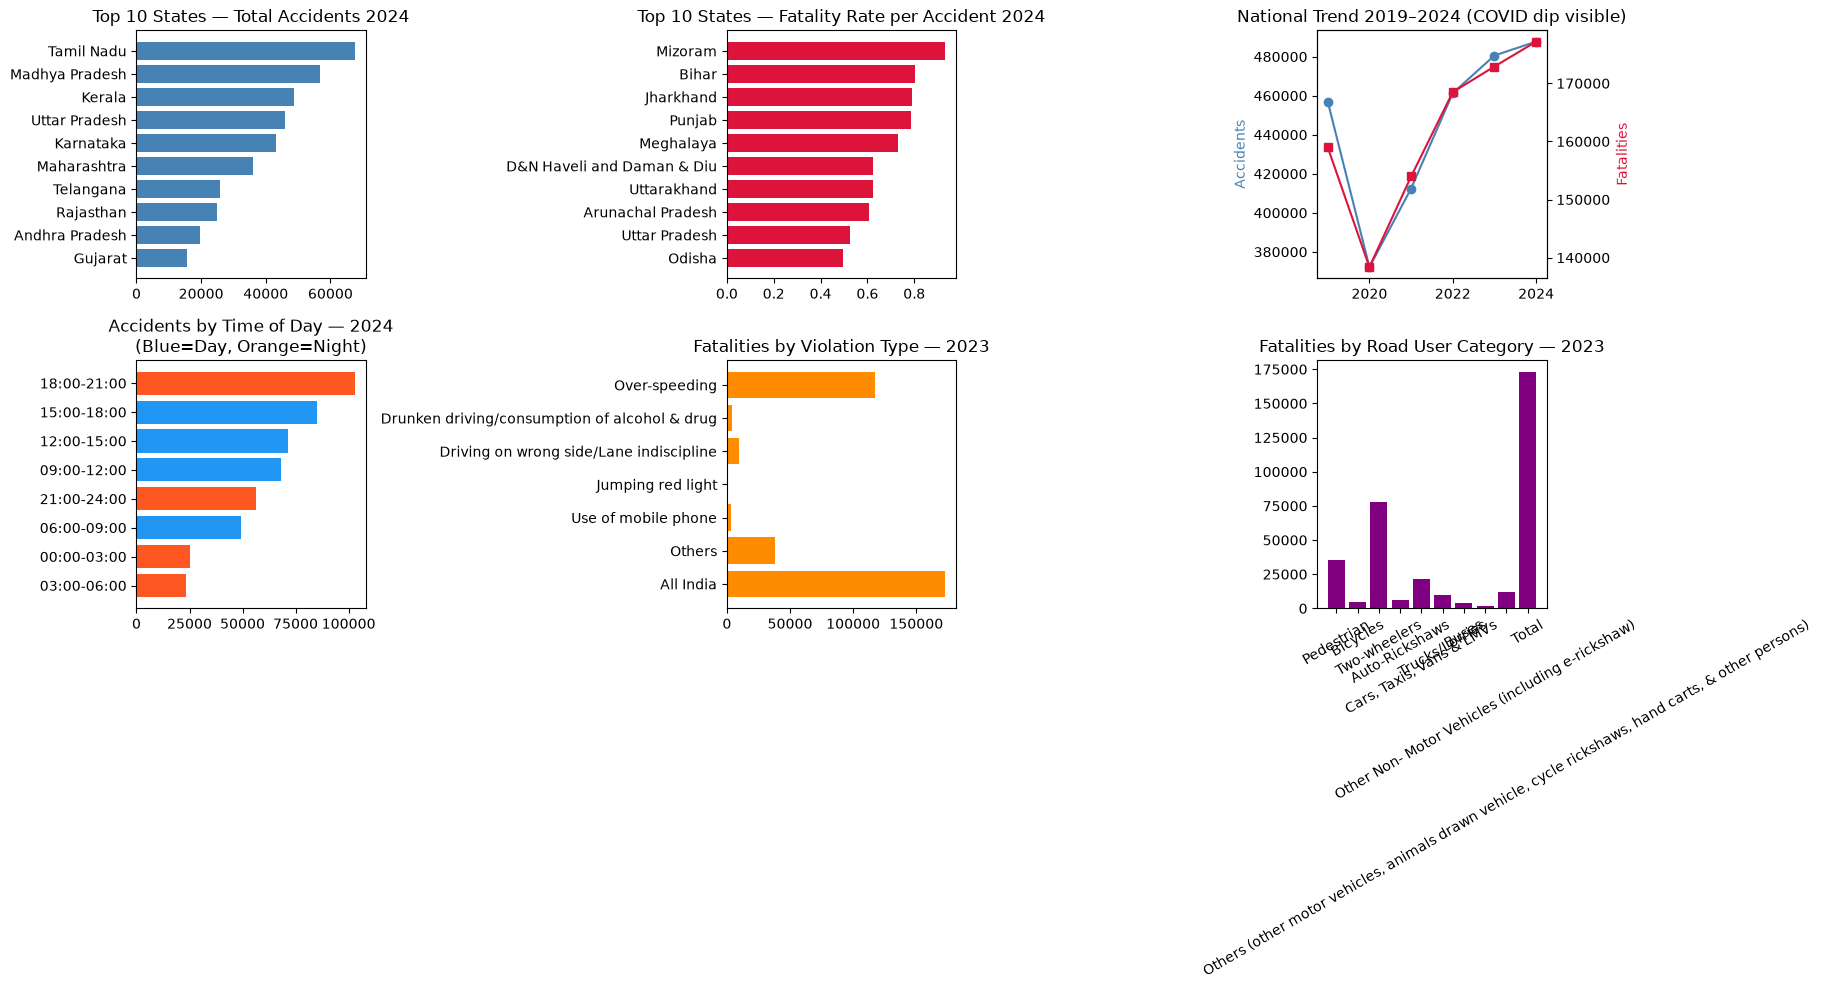

EDA charts saved.


In [12]:
# %% CELL 9 — EDA Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Chart 1: Top 10 states by accidents in 2024 (raw)
latest = state_master[state_master.year == 2024].dropna(subset=['accidents'])
top10_acc = latest.nlargest(10, 'accidents')
axes[0,0].barh(top10_acc['state'], top10_acc['accidents'], color='steelblue')
axes[0,0].set_title('Top 10 States — Total Accidents 2024')
axes[0,0].invert_yaxis()
# Insight: Tamil Nadu #1 in accidents but not #1 in fatalities — density matters

# Chart 2: Top 10 states by FATALITY RATE per accident (your differentiator)
latest_rate = latest.nlargest(10, 'fatality_rate_per_accident')
axes[0,1].barh(latest_rate['state'], latest_rate['fatality_rate_per_accident'], color='crimson')
axes[0,1].set_title('Top 10 States — Fatality Rate per Accident 2024')
axes[0,1].invert_yaxis()
# Insight: High fatality rate = worse road conditions/trauma care, not just more accidents

# Chart 3: National YoY trend 2019-2024
nat = state_master.groupby('year').agg(accidents=('accidents','sum'), fatalities=('fatalities','sum')).reset_index()
axes[0,2].plot(nat['year'], nat['accidents'], marker='o', label='Accidents', color='steelblue')
ax2 = axes[0,2].twinx()
ax2.plot(nat['year'], nat['fatalities'], marker='s', label='Fatalities', color='crimson')
axes[0,2].set_title('National Trend 2019–2024 (COVID dip visible)')
axes[0,2].set_ylabel('Accidents', color='steelblue')
ax2.set_ylabel('Fatalities', color='crimson')

# Chart 4: Time of Day 2024
tod_plot = tod[tod['time_interval'] != 'Unknown'].sort_values('2024_accidents')
axes[1,0].barh(tod_plot['time_interval'], tod_plot['2024_accidents'],
               color=['#2196F3' if t == 'Day' else '#FF5722' for t in tod_plot['time_type']])
axes[1,0].set_title('Accidents by Time of Day — 2024\n(Blue=Day, Orange=Night)')
# Insight: 18:00-21:00 = 21.1% of all accidents — peak commute + fatigue

# Chart 5: Violation type fatalities 2023
viol_plot = viol.copy()
viol_col = [c for c in viol_plot.columns if '2023' in c and 'Killed' in c][0]
axes[1,1].barh(viol_plot.iloc[:,0], viol_plot[viol_col], color='darkorange')
axes[1,1].set_title('Fatalities by Violation Type — 2023')
axes[1,1].invert_yaxis()

# Chart 6: Road user fatalities
ru_plot = ru.copy()
axes[1,2].bar(ru_plot.iloc[:,0], clean_num(ru_plot.iloc[:,2]), color='purple')
axes[1,2].set_title('Fatalities by Road User Category — 2023')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{CLEAN}/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved.")


In [13]:
# %% CELL 10 — Load to PostgreSQL
from sqlalchemy import create_engine

# *** CHANGE THESE TO MATCH YOUR POSTGRES SETUP ***
DB_USER = 'postgres'
DB_PASS = 'Shar$12345'
DB_HOST = 'localhost'
DB_NAME = 'road_accident_db'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}')

tables = {
    'state_master': state_master,
    'vehicle_road_density': density,
    'violation_type': viol,
    'collision_type': coll,
    'road_user_fatalities': ru,
    'large_cities': cities,
    'large_cities_road_user': cities_user,
    'large_cities_violation': cities_viol,
    'victims_vehicles': victims,
    'time_of_day': tod,
}

for name, df in tables.items():
    df.to_sql(name, engine, if_exists='replace', index=False)
    count = pd.read_sql(f'SELECT COUNT(*) FROM {name}', engine).iloc[0,0]
    print(f"  {name}: {count} rows loaded")

print("\nAll tables loaded to PostgreSQL successfully.")

  state_master: 216 rows loaded
  vehicle_road_density: 13 rows loaded
  violation_type: 7 rows loaded
  collision_type: 10 rows loaded
  road_user_fatalities: 10 rows loaded
  large_cities: 51 rows loaded
  large_cities_road_user: 51 rows loaded
  large_cities_violation: 51 rows loaded
  victims_vehicles: 11 rows loaded
  time_of_day: 9 rows loaded

All tables loaded to PostgreSQL successfully.
